**Repository review — 7 September 2026.** Outputs below are preserved from experiment commit 93676de; the updated source has not been re-executed on the original raw data. New safeguards invalidate the old code freeze. Restore the hash-matched inputs and run the experiment driver before Run All. Four historical benchmark quality-exposure exports disagree with summary tables; see REVIEW.md. Return and risk results are unaffected by that export discrepancy.

# Pipeline 2 — market regimes and corporate fundamentals

## TL;DR

This notebook asks whether an explicitly dated corporate-quality penalty adds value beyond regime-aware GMV. It displays coverage, individual facts, score construction, validation sensitivity, test results and uncertainty. Conclusions below are generated from executed results.

**Executed test result (2021-01-04–2026-02-20):** CAGR 8.04%; annual volatility 13.10%; daily CVaR95 1.84%; maximum drawdown 17.88%; annual two-sided turnover 3.25. Interpret these together with the incremental comparisons and uncertainty below.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings, tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "portfolio-mpl"))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The supplied 50 stocks were selected using full-history coverage and alphabetical tie-breaking. Historical delistings and index membership are missing. **Survivorship and universe-selection bias remain.** The data represent a narrow US equity sample, not an emerging market.
6. The original baseline notebook already exposed test results. This test is held out for the **new** hyperparameter choices; it is not a pristine preregistered replication. Previously reported numbers are superseded by the common corrected engine.

## The quality layer

The quality score is a **continuous, interpretable business-quality measure**, not a stock-return prediction and not a copy of the published Quality Minus Junk factor. Four domains receive equal weights:

| Domain | Indicators | Higher quality means |
|---|---|---|
| Profitability | Net income/assets; operating income/revenue | Higher profitability |
| Balance sheet | Equity/assets; cash/assets; liabilities/assets | More equity and cash, fewer liabilities |
| Cash generation | Operating cash flow/assets; free cash flow/assets; accruals/assets | More cash generation, fewer accounting accruals |
| Liquidity | Current assets/current liabilities | More short-term balance-sheet coverage |

Each ratio is cross-sectionally ranked using the information available at that date, reversing the sign where necessary. Rank transformations bound extreme inputs. Missing ratios receive the neutral score 0.5; domains still receive equal weights. There is no backward filling and no quality-based security deletion.

The optimization becomes

`min_w w.T @ [Sigma_regime + lambda * median(diag(Sigma_regime)) * diag(1 - quality)] @ w`.

This is a positive semidefinite diagonal penalty on concentration in lower-quality issuers. It preserves the covariance/diversification framework and the common constraints. At `lambda = 0` it exactly recovers Pipeline 1. At positive lambda, part of the effect is generic regularization, so quality attribution requires a neutral-score control (examined in the comparison notebook).

### Point-in-time data contract

`Ticker -> CIK -> SEC facts -> monthly as-of snapshot -> dated ratios -> quality score -> allocation`.

Facts retain `filed`, `accn`, `start`, `end`, concept and USD units. A fact becomes eligible only after a one-business-day embargo, and its availability date must be no later than the actual previous trading close. This additional calendar check handles exchange holidays. Later restatements are unavailable to earlier portfolios. Annual flows require 330–400 days and 10-K/10-K/A forms; quarterly and year-to-date flows are excluded rather than accidentally mixed. Annual ratios use matching fiscal-year-end denominators. Balance-sheet ratios use a common most recent balance date; denominators must be positive. Facts older than 550 days are not carried indefinitely.

APA and BlackRock need explicitly sourced predecessor CIKs. Predecessor filings stop at the respective legal reorganization; later subsidiary accounts are excluded. BKR uses the current issuer only, leaving earlier coverage missing rather than making an unverified historical splice. Current ticker identity metadata are not used as predictive features.

**Limits:** aggregate XBRL archives are not guaranteed immutable historical vintages, available concepts differ by industry, fiscal year ends differ, and cross-sectional ranks are not sector-neutral. A score change can partly proxy sector composition. News, governance text, analyst revisions and point-in-time credit ratings are not in this score.

## Data

### Build prior-only market snapshots and SEC features

In [2]:
c = prepare_fundamentals(prepare_context())
display(c["summary"])
display(pd.DataFrame([c["fact_audit"]]))
coverage = c["fundamentals"].groupby(c["fundamentals"].date.dt.year)[["quality_coverage", "quality_score"]].mean()
display(coverage.style.format("{:.1%}"))
print("Mapped tickers:", c["sources"].ticker.nunique(), "| source issuer files:", len(c["sources"]))

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,50,213850
validation,2017-01-03,2020-12-31,1007,50,50350
test,2021-01-04,2026-02-20,1289,50,64450


,invalid_or_nonannual_flow_rows,ambiguous_fact_rows_excluded
0,43870,0


,quality_coverage,quality_score
date,,
2010,57.7%,50.7%
2011,78.3%,50.7%
2012,78.8%,50.7%
2013,76.8%,50.7%
2014,76.5%,50.7%
2015,73.5%,50.7%
2016,73.1%,50.7%
2017,73.0%,50.7%
2018,75.4%,50.7%


### Inspect source lineage and missingness

,ticker,cik,entity_name,filing_cutoff_exclusive
1,AAPL,320193,Apple Inc.,None
22,APA,6769,APACHE CORP,2021-03-02
23,APA,1841666,APA CORPORATION,None
43,BKR,1701605,Baker Hughes Company,None
44,BLK,1364742,"BLACKROCK FINANCE, INC.",2024-10-01
45,BLK,2012383,"BlackRock, Inc.",None


,available_ratio_fraction
ticker,
BKR,33.8%
C,44.0%
AXP,53.0%
AIG,55.0%
ACGL,55.8%
BAC,57.0%
BRK.B,59.9%
ARE,62.7%
BRO,62.8%


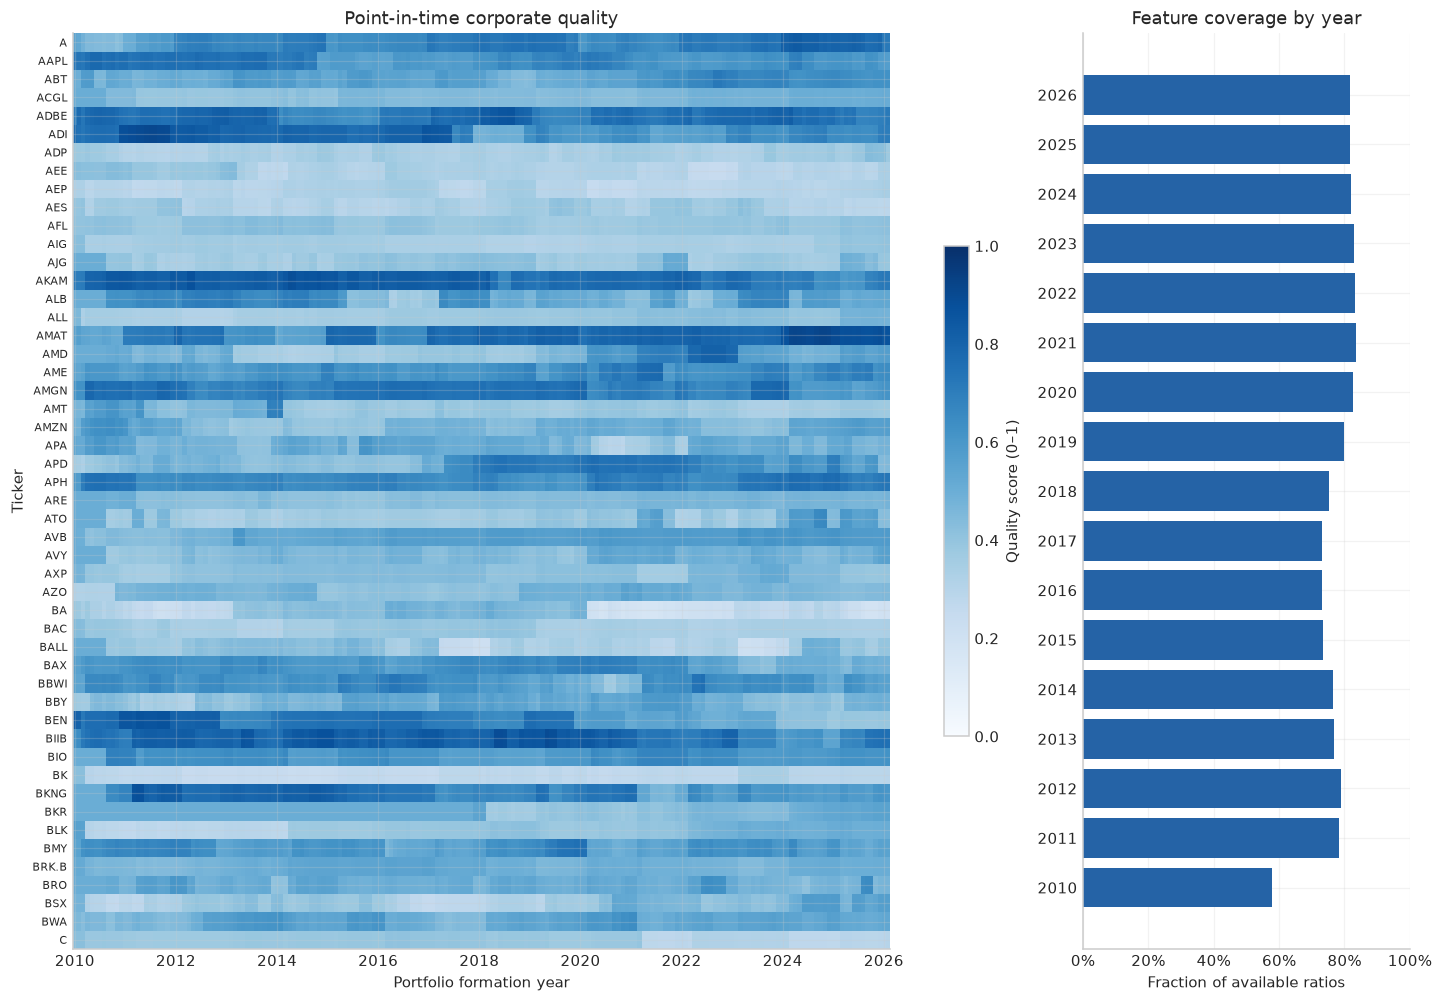

In [3]:
display(c["sources"].loc[c["sources"].ticker.isin(["AAPL", "APA", "BLK", "BKR"]), ["ticker", "cik", "entity_name", "filing_cutoff_exclusive"]])
display(c["fundamentals"].groupby("ticker").quality_coverage.mean().sort_values().head(12).rename("available_ratio_fraction").to_frame().style.format("{:.1%}"))
quality_plot(c["fundamentals"], "pipeline2_quality_coverage")

### Review a formation-date snapshot

The table makes the join reviewable: the last used filing and availability dates precede the portfolio date. Missing values remain visible.

In [4]:
example_date = c["splits"]["validation"][0]
example = c["fundamentals"].query("date == @example_date").set_index("ticker")
display(example[["latest_used_filed", "latest_used_available", "roa", "equity_to_assets", "cfo_to_assets", "quality_coverage", "quality_score"]].head(15))
known = c["fundamentals"].latest_used_available.notna()
assert (c["fundamentals"].loc[known, "latest_used_available"] <= c["fundamentals"].loc[known, "information_date"]).all()
print("Every used filing passes the embargo and as-of join checks.")

,latest_used_filed,latest_used_available,roa,equity_to_assets,cfo_to_assets,quality_coverage,quality_score
ticker,,,,,,,
A,2016-12-20,2016-12-21,0.059216,0.543835,0.101641,1.000000,0.727864
AAPL,2016-10-26,2016-10-27,0.142024,0.398678,NaN,0.666667,0.587315
ABT,2016-11-03,2016-11-04,0.107232,0.526015,0.071908,0.888889,0.527804
ACGL,2016-11-04,2016-11-07,0.023201,0.286716,NaN,0.444444,0.437674
ADBE,2016-09-27,2016-09-28,0.053686,0.588476,0.125315,1.000000,0.708987
ADI,2016-11-22,2016-11-23,0.108110,0.648110,0.160709,0.888889,0.856143
ADP,2016-11-03,2016-11-04,0.034177,0.123775,0.042590,0.777778,0.333163
AEE,2016-11-04,2016-11-07,0.026650,0.298044,0.085321,0.888889,0.334605
AEP,2016-11-02,2016-11-03,0.033272,0.281923,0.076985,1.000000,0.348733


## Results

### Select the quality penalty on validation only

The zero-penalty control competes with four positive strengths. Lower weighted rank score is better; ties prefer the smaller intervention. CVaR is one evaluation component, never the optimization objective.

In [5]:
quality_strength, validation_grid, validation_runs = select_quality(c)
display(styled(validation_grid[["quality_strength", "risk_score"] + METRIC_COLUMNS]))
print("Selected quality strength:", quality_strength)

,quality_strength,risk_score,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
lambda=0,0.000,3.000,16.31%,18.44%,0.912,1.272,32.07%,2.81%,5.74%,4.526,11.567
lambda=0.25,0.250,3.050,15.99%,18.40%,0.899,1.252,32.25%,2.81%,5.74%,4.014,13.343
lambda=0.5,0.500,2.750,15.91%,18.32%,0.898,1.248,32.40%,2.82%,5.72%,3.687,14.884
lambda=1,1.000,2.600,15.94%,18.27%,0.901,1.250,32.90%,2.84%,5.69%,3.365,17.478
lambda=2,2.000,3.600,15.53%,18.40%,0.878,1.212,33.81%,2.89%,5.75%,3.005,21.356


### Inspect how the penalty changes the allocation

In [6]:
from portfolio_research.regimes import solve_gmv
m = c["market"][example_date]
q = example.quality_score.reindex(m["assets"])
penalty = quality_strength * np.median(np.diag(m["regime"])) * (1 - q)
quality_covariance = m["regime"] + np.diag(penalty)
w0, _ = solve_gmv(m["regime"], m["assets"], CONFIG.max_weight)
w1, _ = solve_gmv(quality_covariance, m["assets"], CONFIG.max_weight)
allocation_change = pd.DataFrame({"quality": q, "pipeline1_weight": w0, "pipeline2_weight": w1, "weight_change": w1-w0})
display(allocation_change.reindex(allocation_change.weight_change.abs().sort_values(ascending=False).index).head(15).style.format("{:.3f}"))
assert np.linalg.eigvalsh(quality_covariance).min() > 0

,quality,pipeline1_weight,pipeline2_weight,weight_change
AFL,0.396,0.133,0.066,-0.067
ALL,0.366,0.117,0.067,-0.050
AEP,0.349,0.109,0.068,-0.041
BRK.B,0.558,0.018,0.053,0.036
APH,0.648,0.008,0.042,0.035
BRO,0.493,0.006,0.036,0.030
BAX,0.610,0.000,0.027,0.027
ACGL,0.438,0.103,0.078,-0.025
AME,0.607,0.000,0.024,0.024
AXP,0.437,0.071,0.048,-0.023


### Evaluate the frozen quality strength on the common test

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
baseline,9.16%,13.15%,0.733,1.043,18.63%,1.86%,2.88%,3.235,12.408
pipeline1,9.68%,13.04%,0.774,1.102,18.23%,1.84%,2.84%,4.297,11.585
pipeline2,8.04%,13.10%,0.656,0.932,17.88%,1.84%,2.88%,3.252,17.115


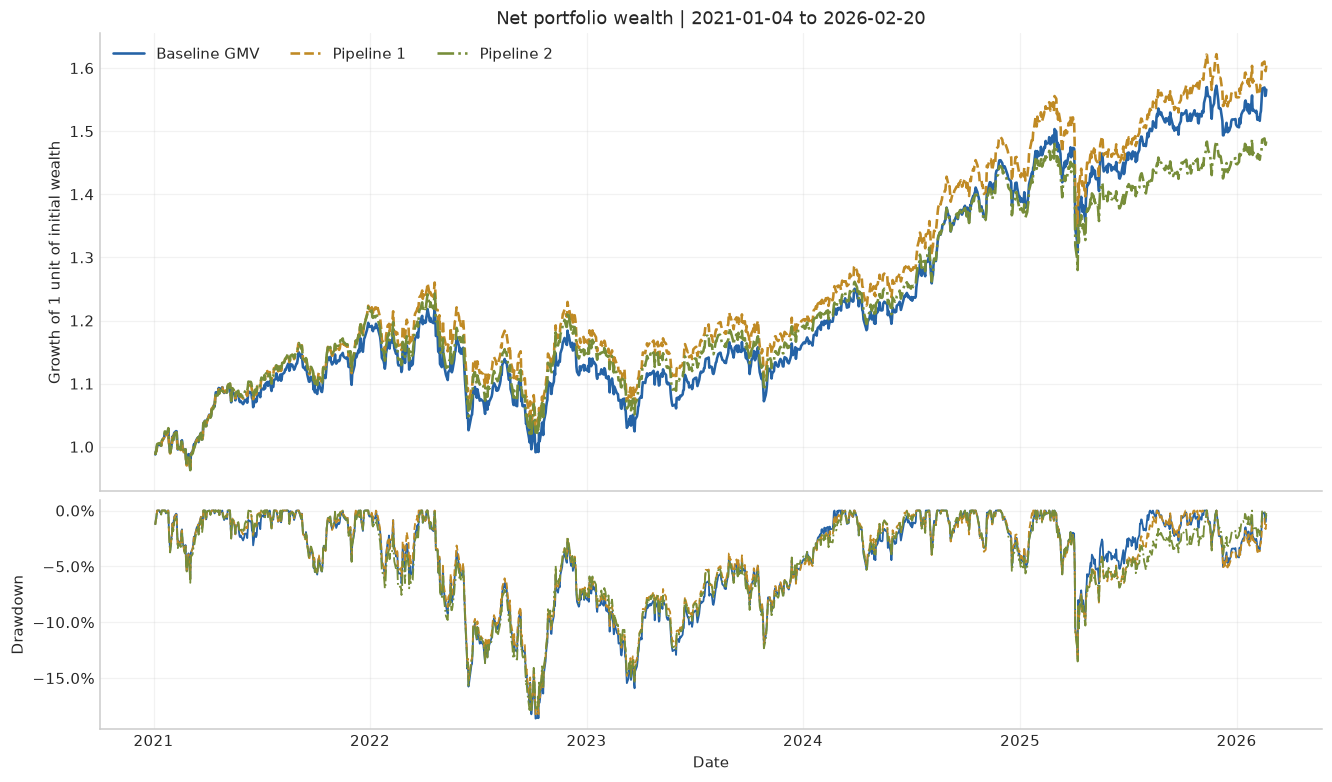

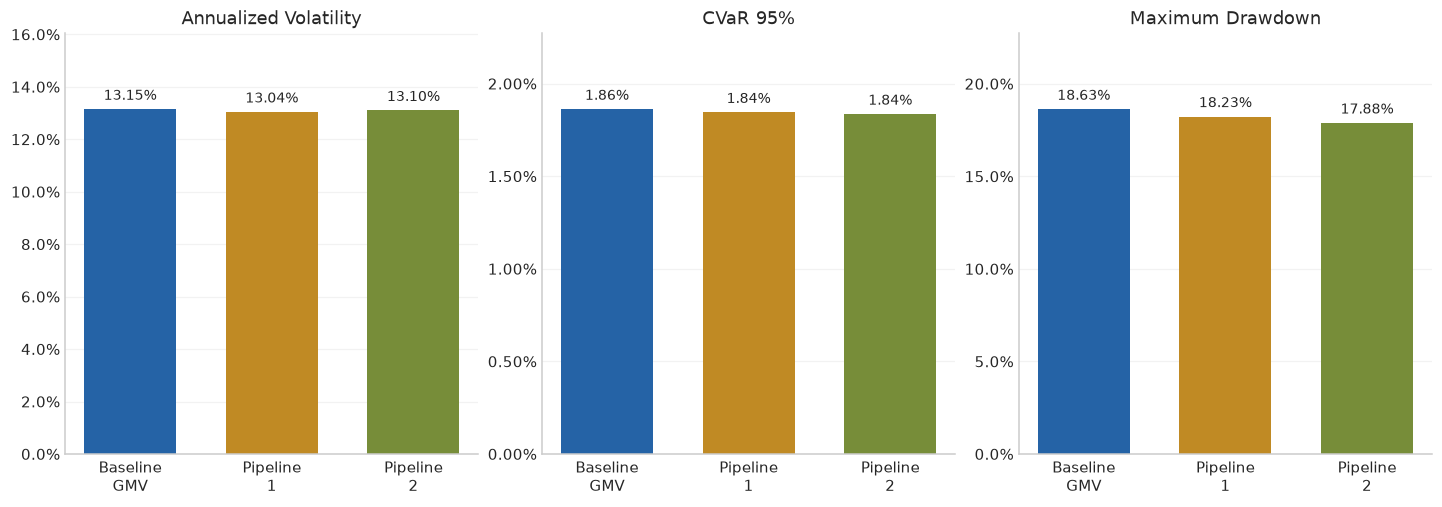

In [7]:
spec = json.loads((ROOT / "artifacts/frozen_spec.json").read_text())
assert quality_strength == spec["quality_strength"], "Selection changed: rerun the experiment driver and freeze before test."
verify_frozen(c, spec)
test_results = {name: strategy(c, "test", name, quality_strength=quality_strength) for name in ["baseline", "pipeline1", "pipeline2"]}
for name, result in test_results.items(): export_result(result, name, "test")
test_table = metric_table(test_results)
display(styled(test_table[METRIC_COLUMNS]))
performance_plot(test_results, "pipeline2_test_performance")
risk_plot(test_table, "pipeline2_test_risk")

### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

,Annualized Turnover,Total Transaction Costs,Average HHI,Average Effective Assets,Mean Target L1 Change,Average Portfolio Quality,Solver Failures
baseline,3.235,1.65%,8.49%,12.408,0.249,0.512,0.000
pipeline1,4.297,2.20%,9.00%,11.585,0.337,0.512,0.000
pipeline2,3.252,1.66%,6.18%,17.115,0.253,0.528,0.000


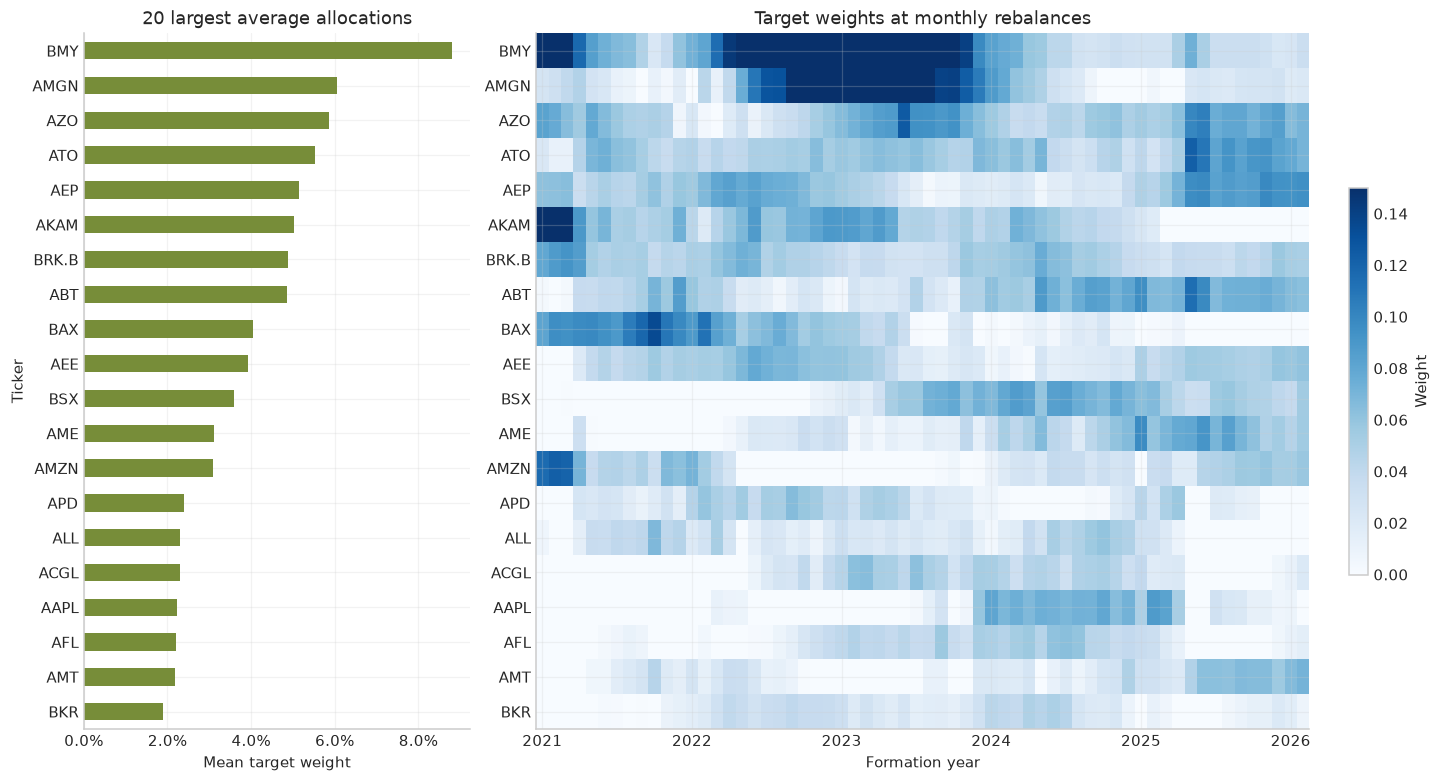

In [8]:
display(styled(test_table[["Annualized Turnover", "Total Transaction Costs", "Average HHI", "Average Effective Assets", "Mean Target L1 Change", "Average Portfolio Quality", "Solver Failures"]]))
allocation_plot(test_results["pipeline2"], "pipeline2_test_weights")

### Incremental uncertainty and publication-lag sensitivity

Intervals compare Pipeline 2 minus Pipeline 1. The extra-lag check delays the already dated monthly quality score by one additional monthly formation, using the same selected penalty. It is a sensitivity experiment, not another hyperparameter search.

In [9]:
uncertainty = paired_bootstrap(test_results["pipeline1"].returns.net_return, test_results["pipeline2"].returns.net_return)
display(uncertainty)
lagged = c["fundamentals"].copy()
lagged["quality_score"] = lagged.groupby("ticker").quality_score.shift(1).fillna(.5)
lagged_result = strategy({**c, "fundamentals": lagged}, "test", "pipeline2", quality_strength)
display(styled(metric_table({"Primary": test_results["pipeline2"], "One extra month": lagged_result})[METRIC_COLUMNS]))

,difference,lower_95,upper_95
Annualized Volatility,0.000580,-0.000723,0.002178
CVaR 95%,-0.000093,-0.000523,0.000405
Maximum Drawdown,-0.003470,-0.022947,0.049699
Sharpe,-0.117695,-0.274913,0.018467


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
Primary,8.04%,13.10%,0.656,0.932,17.88%,1.84%,2.88%,3.252,17.115
One extra month,7.89%,13.11%,0.645,0.916,17.88%,1.84%,2.89%,3.244,17.101


## Takeaways

In [10]:
p1, p2 = test_table.loc["pipeline1"], test_table.loc["pipeline2"]
supported = uncertainty.loc["CVaR 95%", "upper_95"] < 0
display(Markdown(f"""Validation selects **lambda = {quality_strength:g}**. On test, Pipeline 2 has **{p2['CAGR']:.2%} CAGR**, **{p2['Annualized Volatility']:.2%} volatility**, **{p2['CVaR 95%']:.2%} daily CVaR95** and **{p2['Maximum Drawdown']:.2%} maximum drawdown**. Relative to Pipeline 1, CVaR95 changes by {(p2['CVaR 95%']-p1['CVaR 95%'])*100:+.3f} percentage points and annual turnover changes by {p2['Annualized Turnover']-p1['Annualized Turnover']:+.2f}. A lower CVaR is {'supported' if supported else 'not established'} by this descriptive 95% paired interval. Coverage and cross-sector comparability qualify the economic interpretation."""))

Validation selects **lambda = 1**. On test, Pipeline 2 has **8.04% CAGR**, **13.10% volatility**, **1.84% daily CVaR95** and **17.88% maximum drawdown**. Relative to Pipeline 1, CVaR95 changes by -0.009 percentage points and annual turnover changes by -1.05. A lower CVaR is not established by this descriptive 95% paired interval. Coverage and cross-sector comparability qualify the economic interpretation.

## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): original selection and saved splits are preserved. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.